In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.5*size)
train_size = int(size - test_size-valid_size)
trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [8]:
sum=[0]*10
for d,t,i in trainset:
    for i in range(10):
        if(t==i):
            sum[i]+=1
sum

[1467, 1466, 1501, 1457, 1588, 1506, 1484, 1467, 1529, 1535]

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.313524996503194,train_accu=0.5738
Epoch=0,valid_loss=1.3271261205673217,valid_accu=0.5647
0
Epoch=1,train_loss=1.1753359612782797,train_accu=0.6070666666666666
Epoch=1,valid_loss=1.1955420028686523,valid_accu=0.5932
0
Epoch=2,train_loss=1.1049505488713582,train_accu=0.6271333333333333
Epoch=2,valid_loss=1.1306007287025452,valid_accu=0.6146
0
Epoch=3,train_loss=1.062199475669861,train_accu=0.6413333333333333
Epoch=3,valid_loss=1.0930084674835205,valid_accu=0.6237
0
Epoch=4,train_loss=1.02108547929128,train_accu=0.6588666666666667
Epoch=4,valid_loss=1.0535324390411378,valid_accu=0.6434
0
Epoch=5,train_loss=0.9984803072611491,train_accu=0.6615333333333333
Epoch=5,valid_loss=1.0362840227127075,valid_accu=0.646
0
Epoch=6,train_loss=0.9852372058868408,train_accu=0.6610666666666667
Epoch=6,valid_loss=1.0297458971023559,valid_accu=0.6447
Epoch=7,train_loss=0.9695692868550618,train_accu=0.6668666666666667
Epoch=7,valid_loss=1.0169091386795044,valid_accu=0.6442
Epoch=8,train

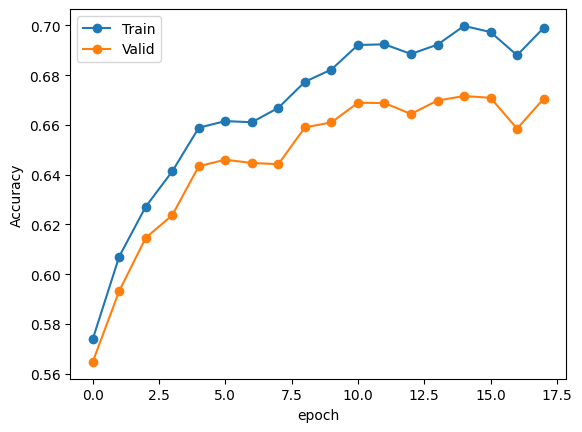

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_13.pth')

In [10]:
summary(model_0,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.8857857347488404, 0.6998)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.949443692779541, 0.6716)

In [13]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airplane      0.684390
automobile    0.762619
bird          0.500999
cat           0.576527
deer          0.770781
dog           0.586321
frog          0.743261
horse         0.708248
ship          0.826030
truck         0.828013
dtype: float64

In [14]:
targetF=[x  for x in each_accu.nsmallest(3).index.map(trainset.dataset.classess)]
targetF

[2, 3, 5]

In [15]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(4464, 10536)

In [16]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3028, 6972)

In [17]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.446822541252772,train_accu=0.7910666666666667
Epoch=0,valid_loss=0.45066606192588804,valid_accu=0.7923
0
Epoch=1,train_loss=0.4230170777638753,train_accu=0.8077333333333333
Epoch=1,valid_loss=0.45869228172302245,valid_accu=0.7808
Epoch=2,train_loss=0.41300391917228696,train_accu=0.8102
Epoch=2,valid_loss=0.45250486402511597,valid_accu=0.781
Epoch=3,train_loss=0.40407259112993876,train_accu=0.8204
Epoch=3,valid_loss=0.39196281199455263,valid_accu=0.8231
0
Epoch=4,train_loss=0.3870281223297119,train_accu=0.8292666666666667
Epoch=4,valid_loss=0.41304827070236205,valid_accu=0.8105
Epoch=5,train_loss=0.379281231546402,train_accu=0.8373333333333334
Epoch=5,valid_loss=0.40500482244491576,valid_accu=0.8165
Epoch=6,train_loss=0.37465234424273175,train_accu=0.8402666666666667
Epoch=6,valid_loss=0.4174256322383881,valid_accu=0.804
3 Early stopping!


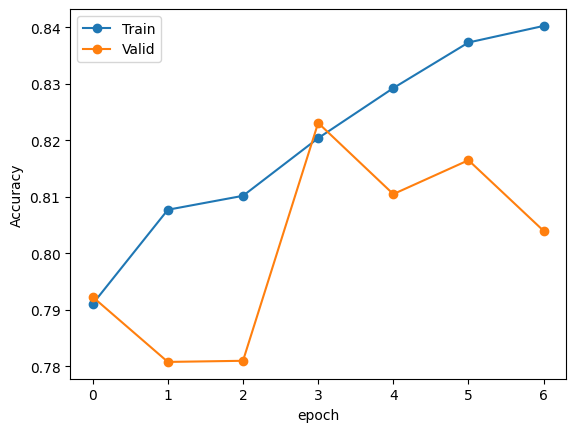

In [42]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",30,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.9925128192546789,train_accu=0.6742596810933941
Epoch=0,valid_loss=0.9998932367279416,valid_accu=0.6675272518646013
0
Epoch=1,train_loss=0.8585546157445162,train_accu=0.7070045558086561
Epoch=1,valid_loss=0.8723385828497487,valid_accu=0.6972174411933448
0
Epoch=2,train_loss=0.7917448632537911,train_accu=0.7277904328018223
Epoch=2,valid_loss=0.8073182548863821,valid_accu=0.719162363740677
0
Epoch=3,train_loss=0.7465288844539437,train_accu=0.7388952164009112
Epoch=3,valid_loss=0.7664588937045375,valid_accu=0.72877223178428
0
Epoch=4,train_loss=0.7157265550273788,train_accu=0.7501898253606681
Epoch=4,valid_loss=0.7361364233651109,valid_accu=0.7432587492828456
0
Epoch=5,train_loss=0.6945770939553245,train_accu=0.7560744115413819
Epoch=5,valid_loss=0.71730615661121,valid_accu=0.7467010900745841
0
Epoch=6,train_loss=0.676365120535831,train_accu=0.7632877752467729
Epoch=6,valid_loss=0.7028278833275476,valid_accu=0.75
0
Epoch=7,train_loss=0.6681202708905452,train_accu=0.760

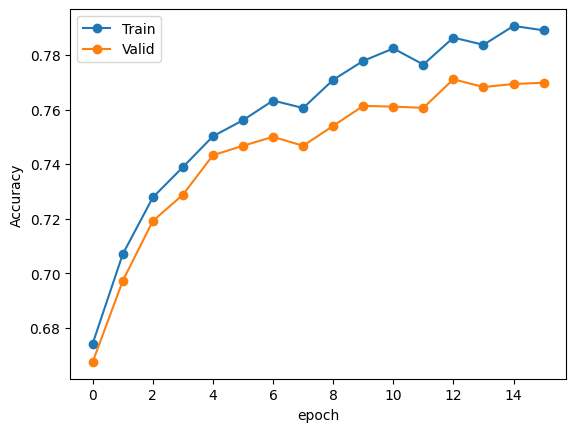

In [21]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [22]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.9058737190820838,train_accu=0.607078853046595
Epoch=0,valid_loss=0.9085653369933799,valid_accu=0.5957727873183619
0
Epoch=1,train_loss=0.812417322589505,train_accu=0.66084229390681
Epoch=1,valid_loss=0.8119249431271219,valid_accu=0.6605019815059445
0
Epoch=2,train_loss=0.7734112778017598,train_accu=0.6758512544802867
Epoch=2,valid_loss=0.7757058580611467,valid_accu=0.6750330250990753
0
Epoch=3,train_loss=0.7428331531076876,train_accu=0.6917562724014337
Epoch=3,valid_loss=0.7492786475027883,valid_accu=0.6928665785997358
0
Epoch=4,train_loss=0.72096036305137,train_accu=0.7036290322580645
Epoch=4,valid_loss=0.7276595415180866,valid_accu=0.6971598414795245
0
Epoch=5,train_loss=0.7052205061827082,train_accu=0.7078853046594982
Epoch=5,valid_loss=0.7158111872414774,valid_accu=0.6991413474240423
0
Epoch=6,train_loss=0.6964288065510411,train_accu=0.71415770609319
Epoch=6,valid_loss=0.7092931261150809,valid_accu=0.7093791281373845
0
Epoch=7,train_loss=0.6867119135822447,trai

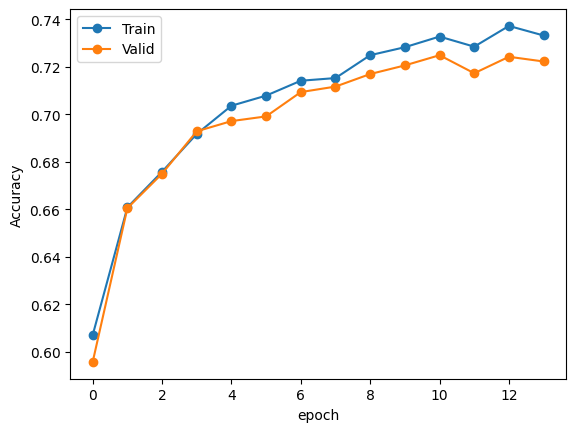

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.42253072217305504, 0.8056)

In [25]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.4132845338821411, 0.8128)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.6086974116374619, 0.7863515565679575)

In [27]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.6588029959723086, 0.7327508960573477)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.6485385360282793, 0.7710843373493976)

In [29]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.6778823425464302, 0.7249009247027741)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.6236089224179586, 0.7704666666666666, 4464)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.657423486995697, 0.7571, 3028)

In [33]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum

(2.3872284907658896, 0.6307333333333334, 5324)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum

(2.422177727127075, 0.6231, 3622)

In [35]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [36]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.885786,0.699800,0.949444,0.671600
1,Model_Decision,0.422531,0.805600,0.422531,0.812800
2,Model_T,0.608697,0.786352,0.648539,0.771084
3,Model_F,0.658803,0.732751,0.677882,0.724901
4,Total_Model,2.387228,0.630733,2.422178,0.623100
5,Total_Model_without_decision,0.623609,0.770467,0.657423,0.757100


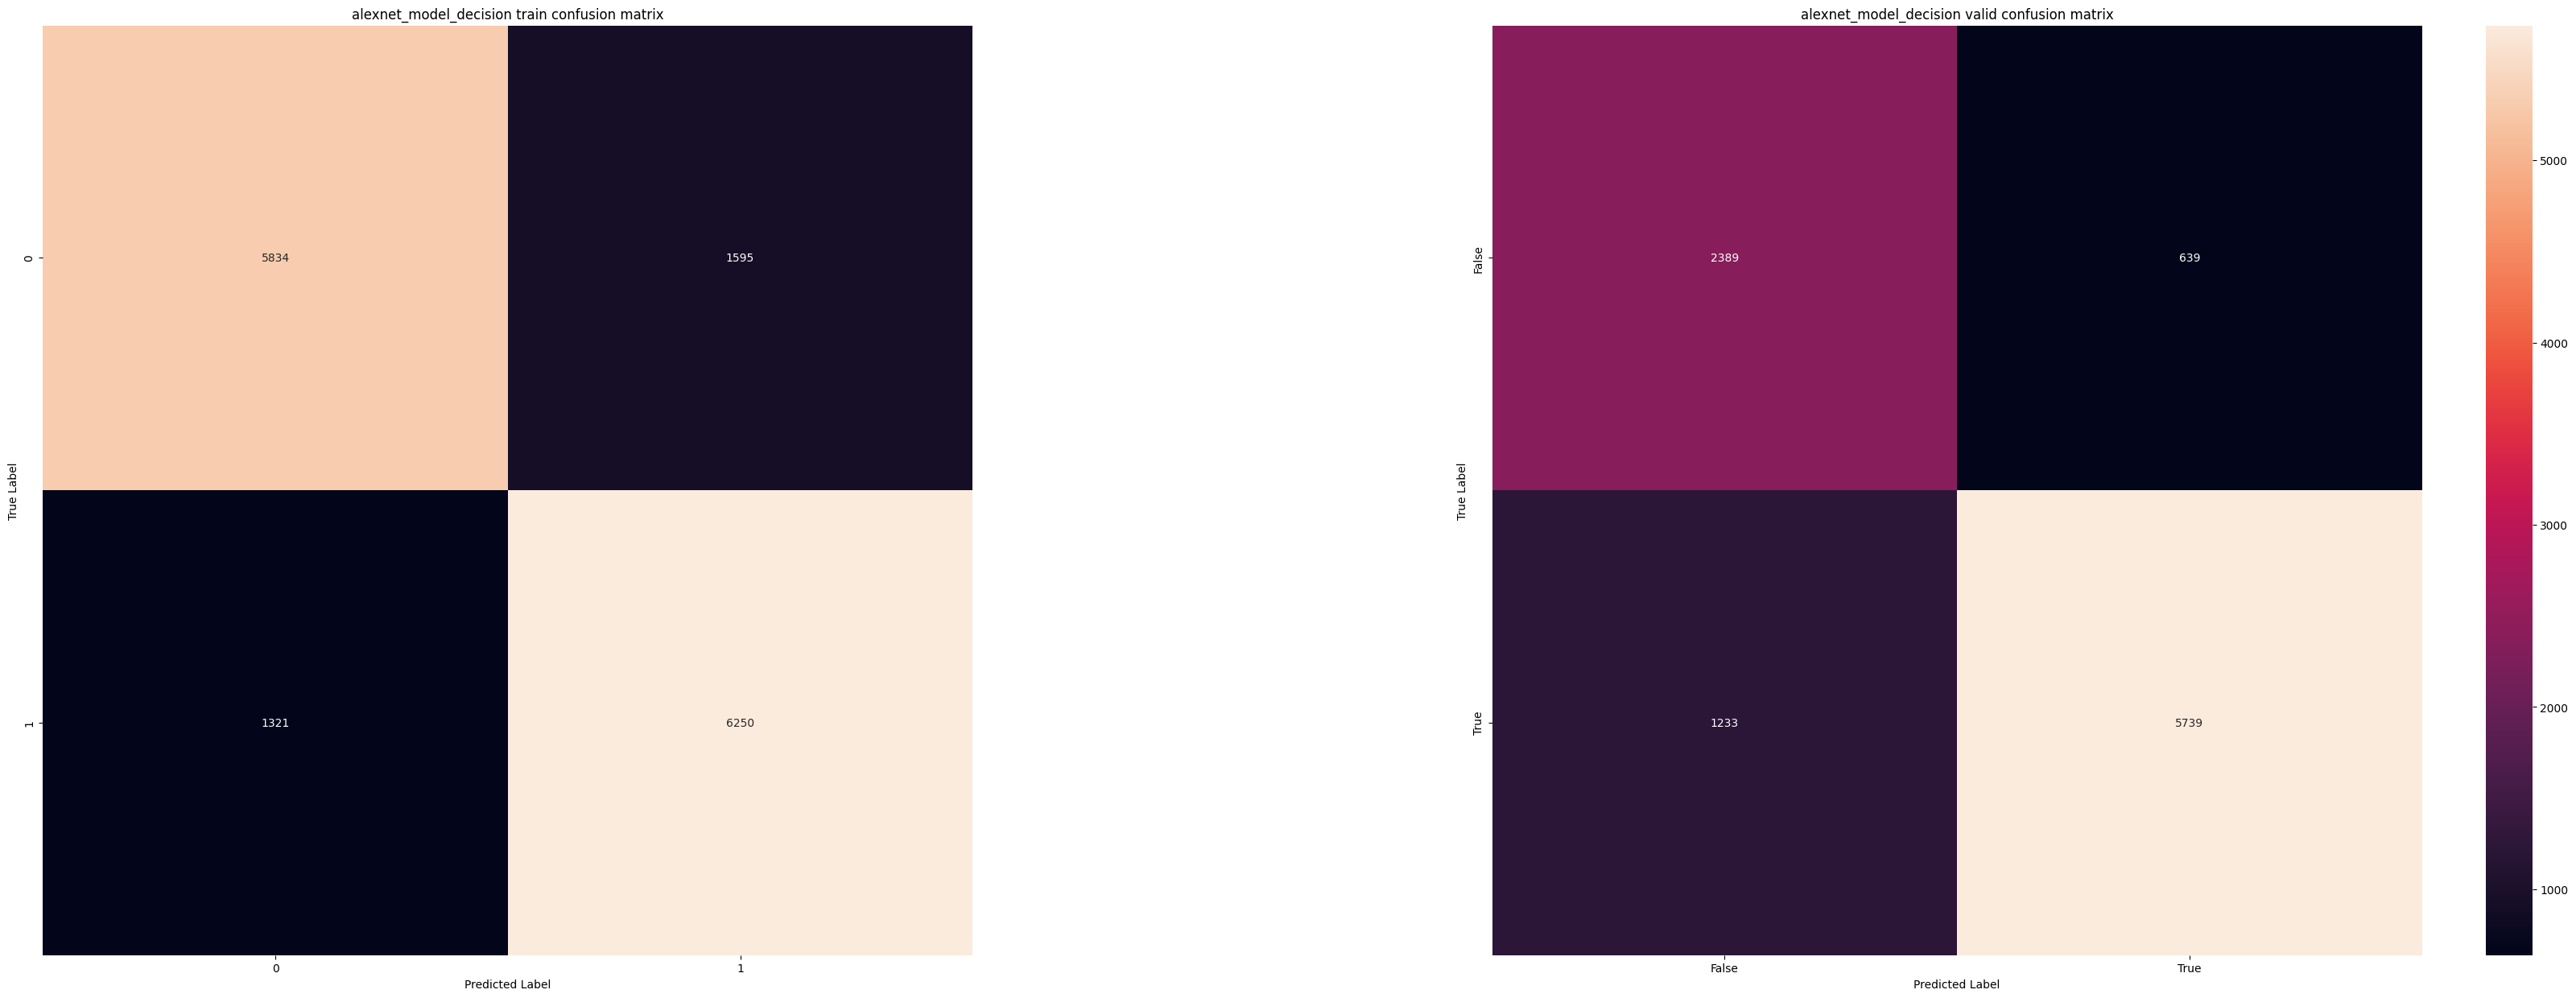

In [37]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

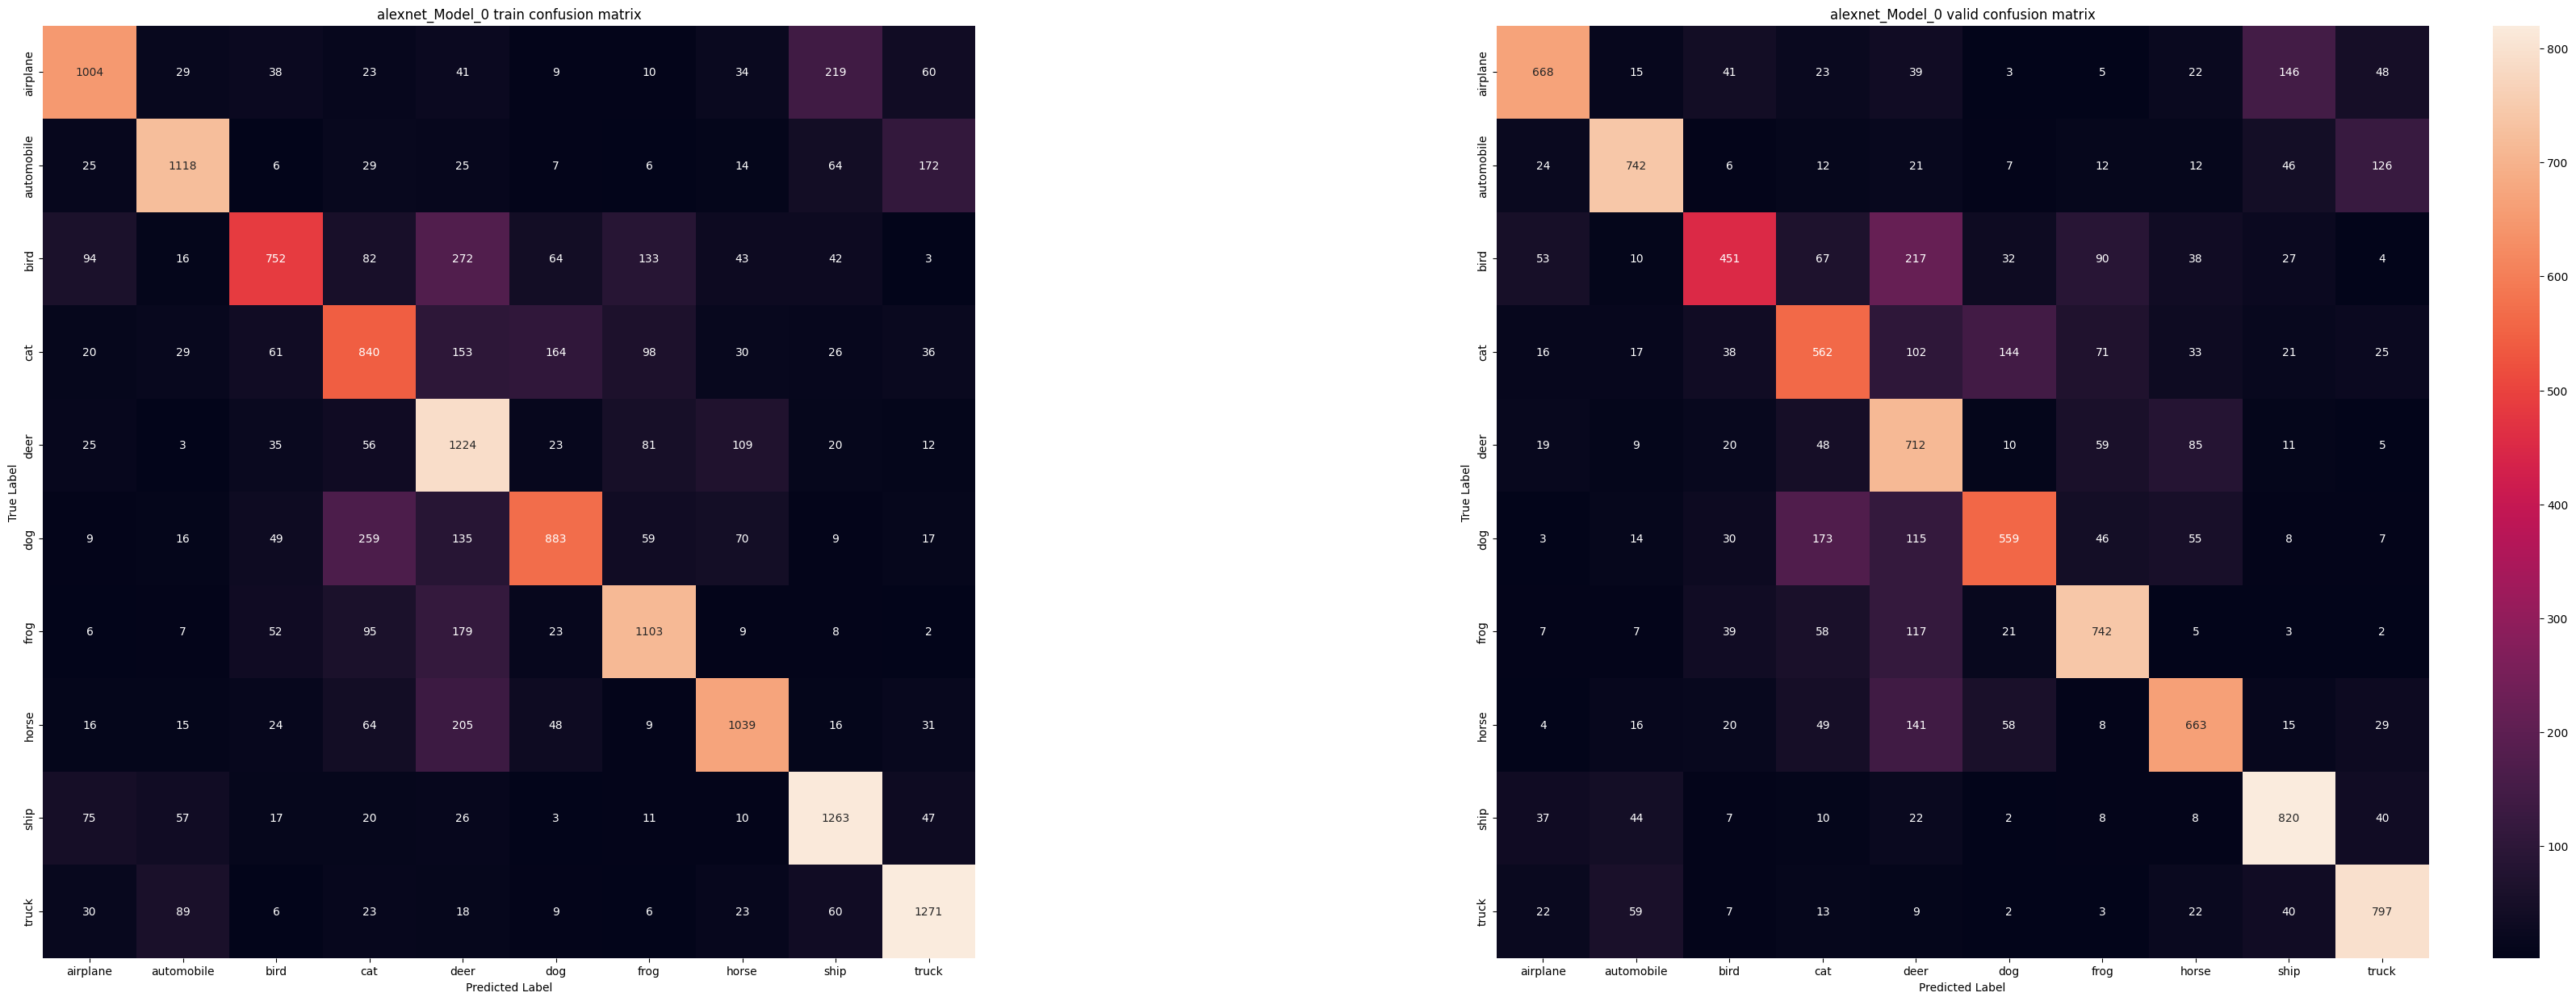

In [38]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

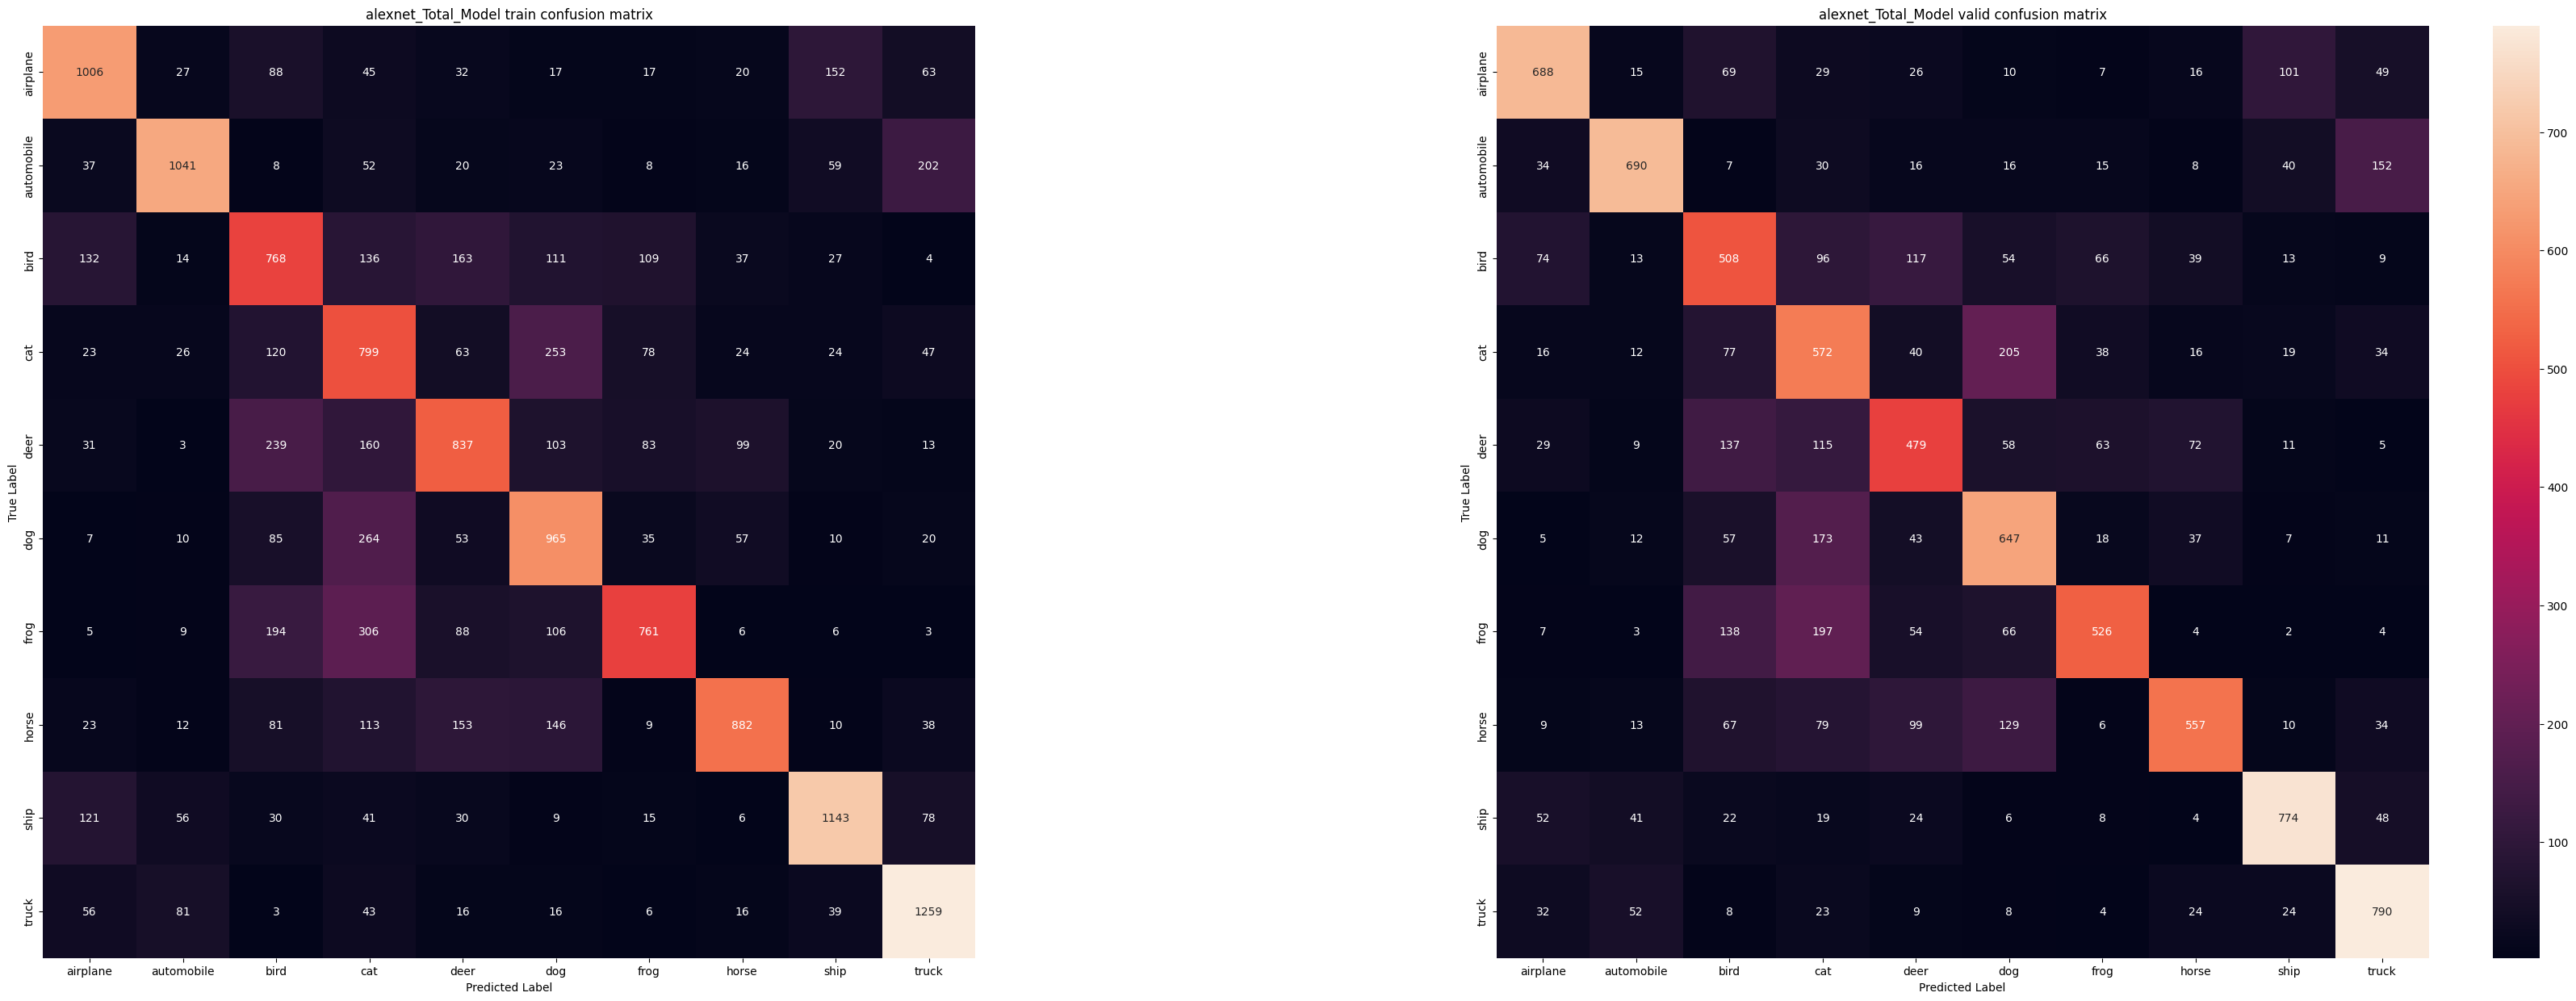

In [39]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

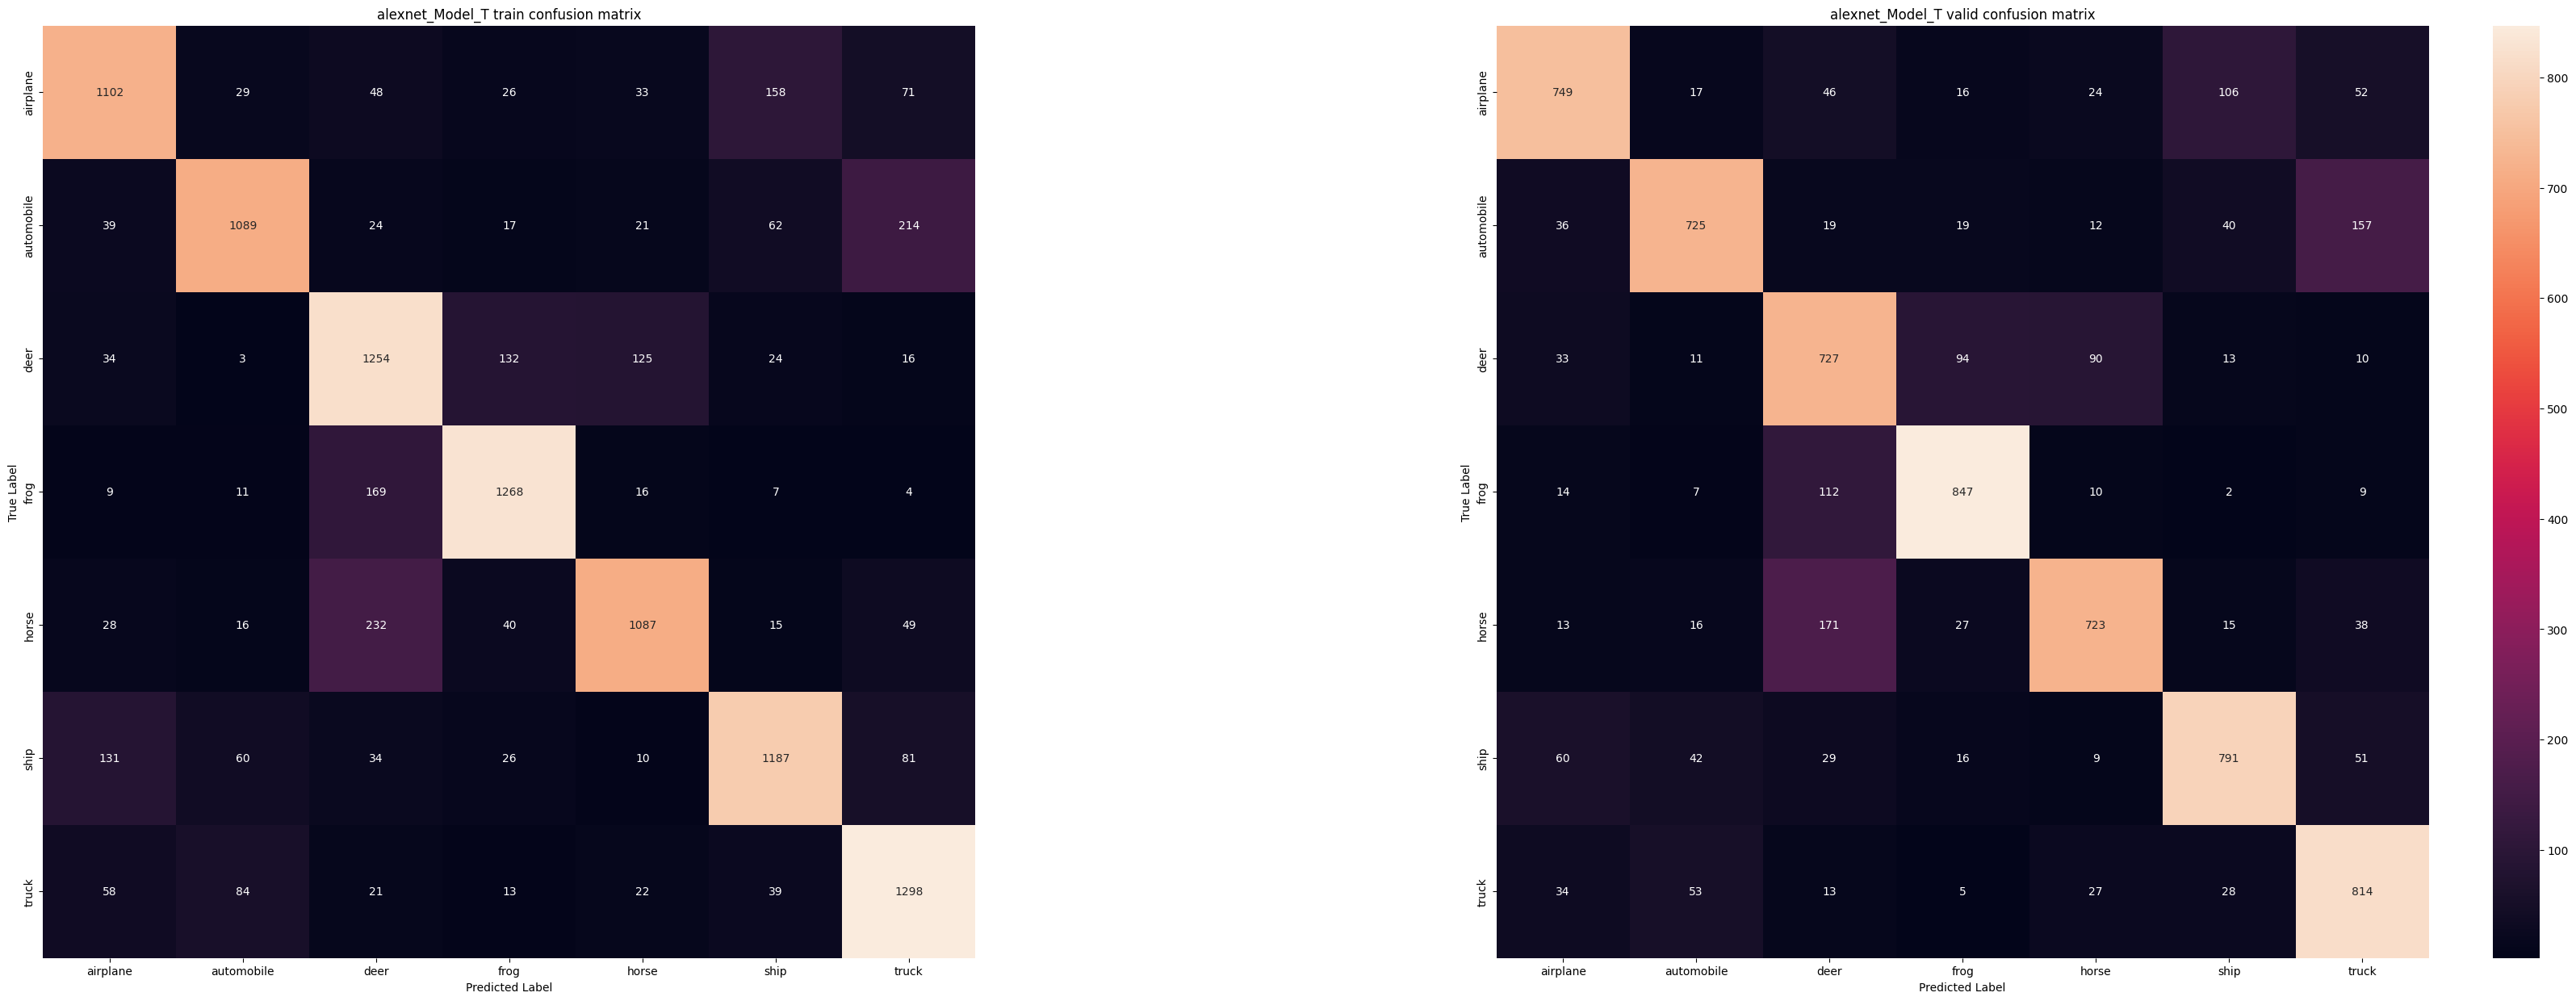

In [40]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

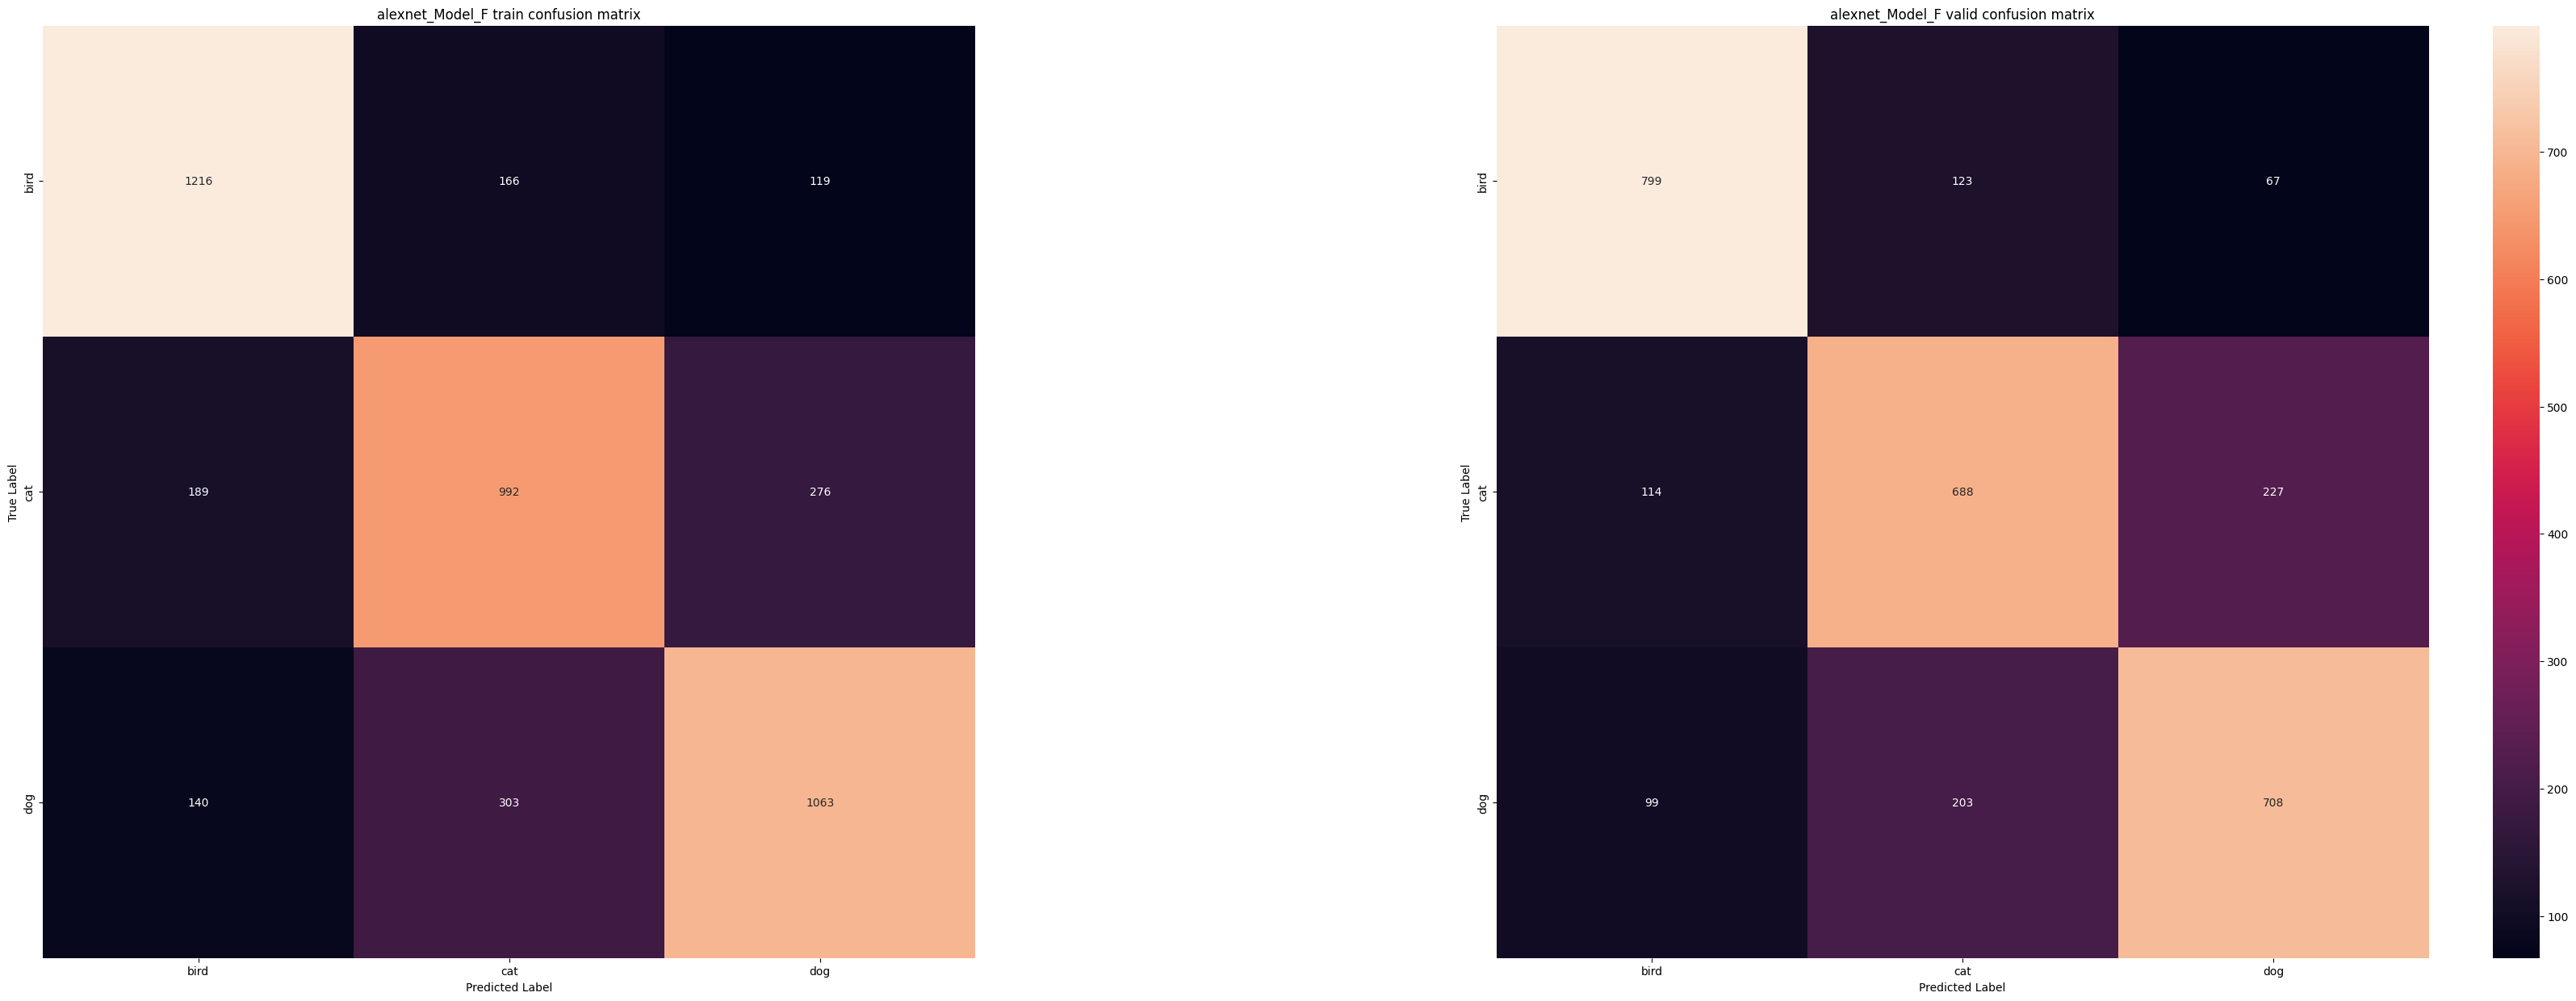

In [41]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)